# **Project Name -** **Gold Price Prediction**

---
Project Type - **Time Series Forecasting**

Project Source - **Kaggle**

Contributors - **Sagar Jain**


# **Project Overview**

**Problem Statement**

Gold prices fluctuate due to market demand, economic conditions, inflation, and global uncertainty. Understanding historical price patterns can help in identifying trends and predicting future price movements.

The objective of this project is to analyze historical gold price data, perform exploratory data analysis to identify patterns and trends, and build time series forecasting models to predict future gold prices. The project will use statistical techniques and machine learning models to understand price behavior and improve forecasting accuracy.

**Project Summary**

**Github Link**

https://github.com/Sagarjain93/Machine-Learning-Portfolio/tree/main/03_ML_Practice/Gold_Price_Prediction_Forecasting

# **Import Required Libraries**

In [1]:
# ============================================
# DATA MANIPULATION LIBRARIES
# ============================================

import pandas as pd                # For data manipulation and analysis
import numpy as np                 # For numerical operations


# ============================================
# DATA VISUALIZATION LIBRARIES
# ============================================

import matplotlib.pyplot as plt    # Basic plotting library
import seaborn as sns              # Advanced statistical visualizations

# Setting visualization style
sns.set(style="whitegrid")


# ============================================
# TIME SERIES ANALYSIS LIBRARIES
# ============================================

from statsmodels.tsa.stattools import adfuller     # Augmented Dickey-Fuller test (stationarity check)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # ACF and PACF plots
from statsmodels.tsa.seasonal import seasonal_decompose         # Decompose time series


# ============================================
# STATISTICAL TESTING
# ============================================

from scipy import stats            # For hypothesis testing


# ============================================
# MACHINE LEARNING LIBRARIES
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================
# MACHINE LEARNING MODELS
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# ============================================
# TIME SERIES MODELS
# ============================================

from statsmodels.tsa.arima.model import ARIMA


# ============================================
# IGNORE WARNINGS
# ============================================

import warnings
warnings.filterwarnings("ignore")

# **Data Collection & Data Loading**

**Clone GitHub Repository in Colab**

In [2]:
# Clone your GitHub repository into the Colab environment
!git clone https://github.com/Sagarjain93/Machine-Learning-Portfolio.git

Cloning into 'Machine-Learning-Portfolio'...
remote: Enumerating objects: 667, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (211/211), done.
remote: Total 667 (delta 155), reused 15 (delta 15), pack-reused 441 (from 2)
Receiving objects: 100% (667/667), 19.64 MiB | 18.17 MiB/s, done.
Resolving deltas: 100% (408/408), done.


**Navigate to Dataset Folder**

In [3]:
# List files inside the raw data folder
!ls Machine-Learning-Portfolio/03_ML_Practice/Gold_Price_Prediction_Forecasting/01_raw_data

gold_price_raw_data.csv


**Load the CSV File**

In [4]:
# Define the file path to the dataset inside the cloned repository
file_path = "Machine-Learning-Portfolio/03_ML_Practice/Gold_Price_Prediction_Forecasting/01_raw_data/gold_price_raw_data.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# **Initial Data Exploration**

**Preview the dataset**

In [5]:
# Display the first 5 rows of the dataset
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77


In [6]:
# Display the last 5 rows of the dataset
df.tail()

,Date,Price,Open,High,Low,Volume,Chg%
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3103,2014-01-01,29542,29435,29598,29340,2930,0.25


**Check Dataset Shape**

In [7]:
# Check number of rows and columns in the dataset
print(f"The dataset has {df.shape[0]} rows")
print(f"The dataset has {df.shape[1]} columns")

The dataset has 3104 rows
The dataset has 7 columns


**Column Names**

In [8]:
df.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')

**Dataset Information**

In [9]:
# Get information about data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB


**Summary Statistics**

In [10]:
# Generate summary statistics for numerical columns
df.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


**Check Missing Values**

In [11]:
# Check number of missing values in each column

df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Volume,0
Chg%,0


**Check Duplicate Rows**

In [12]:
# Check if duplicate rows exist in the dataset

df.duplicated().sum()

np.int64(0)

### **Observations from Initial Data Exploration**

- The dataset contains **3104 observations** and **7 features**.
- There are **no missing values** present in the dataset.
- No **duplicate rows** were found.
- Most columns have appropriate numeric data types.
- The **Date column is currently stored as an object and needs to be converted to datetime format** for proper time series analysis.

# **Data Cleaning**

**1. Convert Date Column to Datetime**

In [13]:
# Convert the 'Date' column from object to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the datatype again to confirm conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3104 non-null   datetime64[ns]
 1   Price   3104 non-null   int64         
 2   Open    3104 non-null   int64         
 3   High    3104 non-null   int64         
 4   Low     3104 non-null   int64         
 5   Volume  3104 non-null   int64         
 6   Chg%    3104 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 169.9 KB


**2. Sort Dataset by Date**

In [14]:
# Sort the dataset by Date in ascending order
df = df.sort_values(by="Date")

# Display first few rows after sorting
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
3103,2014-01-01,29542,29435,29598,29340,2930,0.25
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55


**3. Reset Index**

In [15]:
# Reset the index after sorting
df = df.reset_index(drop=True)

# Display first few rows
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2014-01-01,29542,29435,29598,29340,2930,0.25
1,2014-01-02,29975,29678,30050,29678,3140,1.47
2,2014-01-03,29727,30031,30125,29539,3050,-0.83
3,2014-01-04,29279,29279,29279,29279,0,-1.51
4,2014-01-06,29119,29300,29395,29051,24380,-0.55


**4. Set Date as Index**

In [16]:
# Set Date column as the dataframe index
df.set_index("Date", inplace=True)

# Display first few rows
df.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


**5. Final Check**

In [17]:
# Check dataset structure after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3104 entries, 2014-01-01 to 2026-01-02
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3104 non-null   int64  
 1   Open    3104 non-null   int64  
 2   High    3104 non-null   int64  
 3   Low     3104 non-null   int64  
 4   Volume  3104 non-null   int64  
 5   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 169.8 KB


In [18]:
df.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


### **Data Cleaning Observations**

- The **Date column was converted to datetime format** to enable time series operations.
- The dataset was **sorted chronologically** to maintain correct temporal order.
- The **Date column was set as the index**, which allows easier time-based analysis.
- Some dates are missing because **financial markets are closed on weekends and holidays**, which is expected for trading datasets.

# **EDA**

## **UNIVARIATE ANALYSIS**

### **Chart 1 — Distribution of Gold Prices**

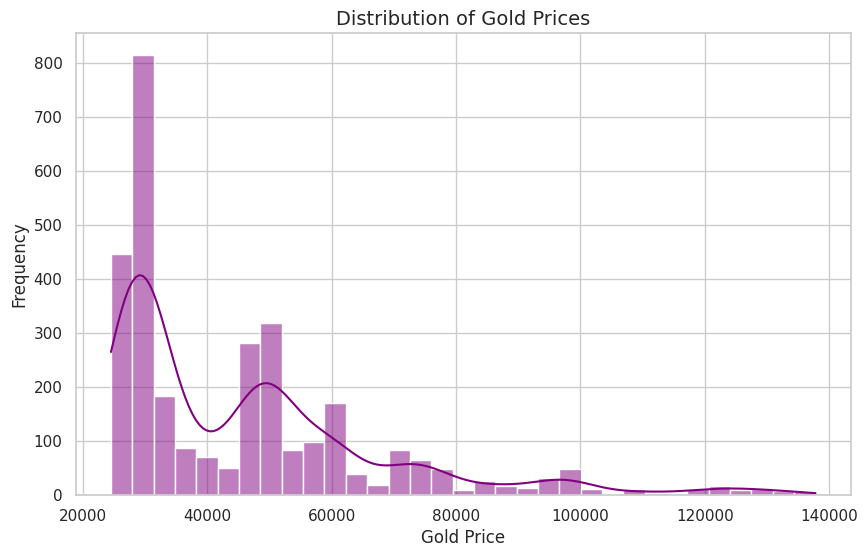

In [19]:
# Chart 1: Distribution of Gold Prices

# This chart helps understand how gold prices are distributed in the dataset

plt.figure(figsize=(10,6))  # Set figure size

# Histogram with KDE curve to visualize distribution
sns.histplot(df["Price"], kde=True, color="purple")

# Chart title and labels
plt.title("Distribution of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Frequency")

# Display chart
plt.show()

#### **Why this chart is used**

A Histogram with KDE is used to understand the distribution of a numerical variable.

It helps us see:

*  How gold prices are spread across the dataset

*  Whether the data is normal, left-skewed, or right-skewed

*  Whether there are multiple peaks or clusters

This is important before building models because skewed distributions can affect statistical assumptions.

#### **Insight from the chart**

From the histogram we can observe:

*  The distribution is right-skewed (positively skewed).

*  Most gold prices are concentrated roughly between: ₹25,000 – ₹60,000

*  There are fewer observations at very high prices, which stretch the tail toward ₹120,000+.

*  The dataset seems to contain multiple peaks, suggesting different price regimes over time.

This happens because gold prices increase significantly across years.

#### **Business Insight**

**Positive Insight**

Gold prices show a long-term upward trend, meaning the asset has appreciated significantly over time. This reinforces gold's reputation as a strong long-term investment and hedge against inflation.

**Market Insight**

The right skew suggests that recent years contain much higher prices compared to older years, which is expected due to economic factors like inflation, demand, and global uncertainty.

### **Chart 2: Boxplot of Gold Prices**

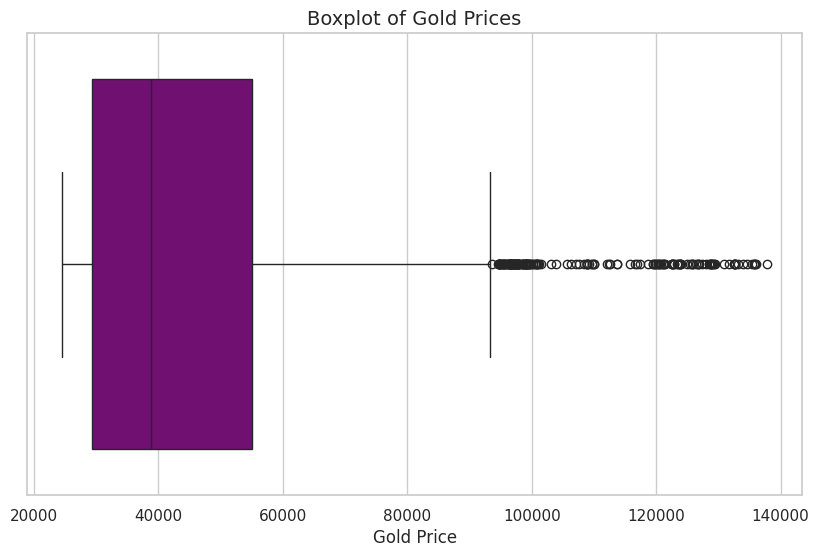

In [20]:
# Chart 2: Boxplot of Gold Prices

# This chart helps detect outliers and understand the spread of gold prices

plt.figure(figsize=(10,6))  # set figure size

# Boxplot visualization
sns.boxplot(x=df["Price"], color="purple")

# Chart title and labels
plt.title("Boxplot of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")

# Display the chart
plt.show()

#### **Why this chart is used**

A Boxplot is used to understand:

*  Spread of the data

*  Median value

*  Interquartile range (IQR)

*  Presence of outliers

Unlike histograms, boxplots clearly highlight extreme values in the dataset.

For financial datasets like gold prices, this helps us detect price spikes or unusual market movements.

#### **Insight from the chart**

From the boxplot we can observe:

*  The median gold price appears around: ~ ₹38,000 – ₹40,000

*  The interquartile range (IQR) roughly lies between: ₹30,000 – ₹55,000

*  Meaning 50% of gold prices fall within this range.

*  There are many outliers on the right side of the plot.

*  These represent very high gold prices observed in later years.

*  The distribution again confirms right skewness, which we already saw in Chart 1.

#### **Business Insight**

**Positive Insight**

*  The presence of many high-value outliers indicates that gold prices increased significantly in later years, reflecting strong long-term growth.

*  This supports gold's role as a safe-haven asset during inflation and economic uncertainty.

**Market Behavior Insight**

*  These "outliers" are not errors.
*  They represent structural market growth over time.

* So we should NOT remove these values, because they contain important financial information.

### **Chart 3: Distribution of Trading Volume**

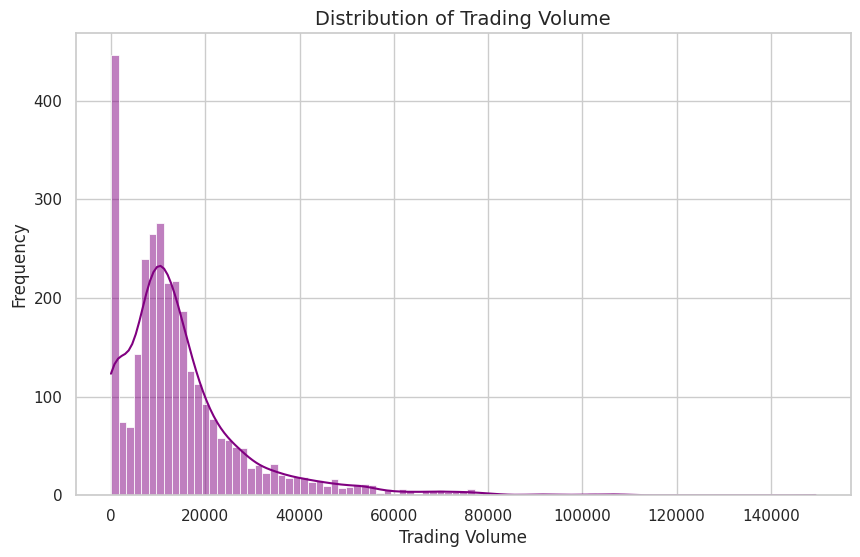

In [21]:
# Chart 3: Distribution of Trading Volume

# This chart helps understand how trading activity (volume)
# is distributed across the dataset and whether trading is consistent or irregular.

plt.figure(figsize=(10,6))  # Set figure size

# Histogram with KDE to visualize distribution of trading volume
sns.histplot(df["Volume"], kde=True, color="purple")

# Chart title and labels
plt.title("Distribution of Trading Volume", fontsize=14)
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")

# Display the chart
plt.show()

#### **Why this chart is used**

*  A Histogram with KDE is used to understand the distribution of trading activity in the market.

*  Trading Volume represents the number of contracts traded on a given day.
Analyzing its distribution helps us understand:

    *  Whether trading activity is consistent or highly volatile

    *  Whether there are days with extremely high trading activity

    *  How frequently high-volume events occur

*  This is important because volume often reflects market sentiment and investor participation.

#### **Insight from the chart**

From the chart we can observe:

*  The distribution is heavily right-skewed.

*  Most trading volume is concentrated roughly between: 0 – 20,000

*  There are few days with extremely high volume, extending up to around: 150,000

*  The large spike near very low volumes suggests that many days have relatively low trading activity.


#### **Business Insight**

**Market Insight**

*  The gold market generally experiences moderate daily trading activity, with occasional spikes in trading volume.

*  These spikes may correspond to:

    *  Major economic announcements

    *  Geopolitical events

    *  Inflation concerns

    *  market volatility periods

    *  Risk / Opportunity Insight

*  High-volume spikes often indicate strong market reactions and may signal important turning points or strong trends in gold prices.

*  Traders and analysts often monitor volume spikes to identify potential buying or selling pressure in the market.

### **Chart 4: Distribution of Daily Percentage Change (Chg%)**

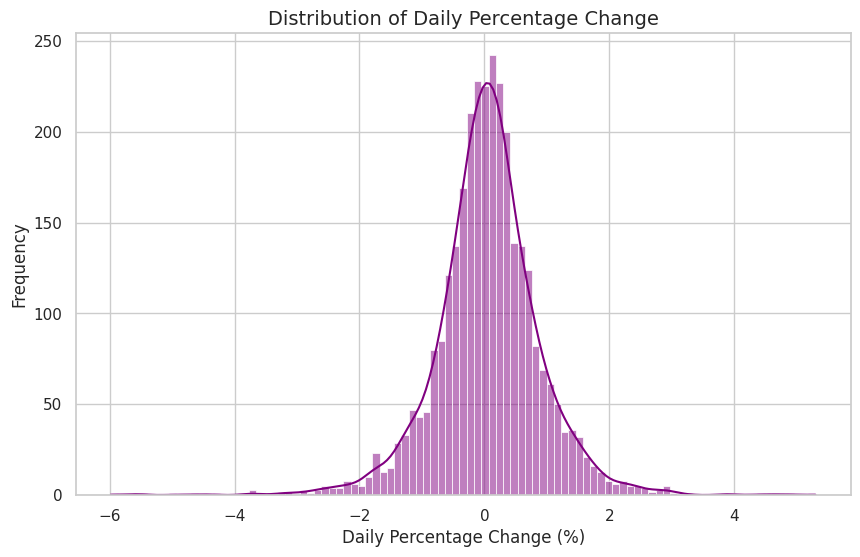

In [22]:
# Chart 4: Distribution of Daily Percentage Change (Chg%)

# This chart helps us understand daily market volatility.
# It shows how frequently gold prices increase or decrease in percentage terms.

plt.figure(figsize=(10,6))  # set figure size

# Histogram with KDE to visualize distribution of daily % change
sns.histplot(df["Chg%"], kde=True, color="purple")

# Chart title and axis labels
plt.title("Distribution of Daily Percentage Change", fontsize=14)
plt.xlabel("Daily Percentage Change (%)")
plt.ylabel("Frequency")

# Display chart
plt.show()

#### **Why this chart is used**

*  This Histogram with KDE is used to understand market volatility.

*  The Chg% (Daily Percentage Change) shows how much the gold price moves up or down each day.

*  Analyzing this helps us understand:

    *  How frequently gold prices increase or decrease

    *  Whether the market is stable or highly volatile

    *  Whether extreme price movements occur

*  This is very important in financial time series analysis.

#### **Insight from the chart**

From the chart we can observe:

*  The distribution is approximately normal (bell-shaped).

*  Most daily price changes lie between: -1% to +1%

*  The center of the distribution is around 0%, meaning gold prices typically have small daily movements.

*  There are few extreme movements reaching around: -6% to +5%

*  These represent rare market shocks.


#### **Business Insight**

**Market Stability Insight**

*  The gold market generally shows low daily volatility, meaning prices move gradually rather than drastically.

*  This is one reason gold is considered a relatively stable investment asset.

**Risk Insight**

*  Occasional large percentage changes indicate market reactions to major events, such as:

    *  Global financial crises

    *  Inflation announcements

    *  Geopolitical tensions

    *  currency fluctuations

*  These events can trigger temporary spikes in volatility.

### **Chart 5: Density Plot of Gold Prices**

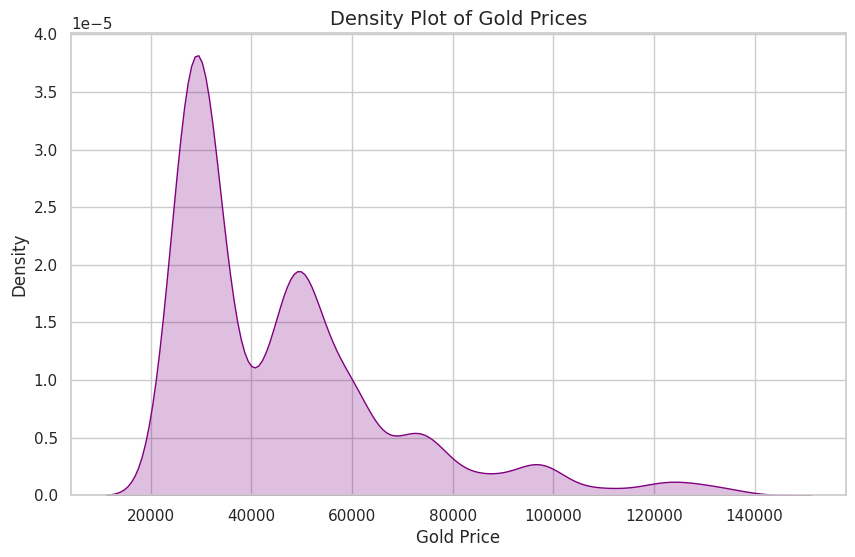

In [23]:
# Chart 5: Density Plot of Gold Prices

# This chart shows the probability density of gold prices.
# It helps understand where the prices are most concentrated in the dataset.

plt.figure(figsize=(10,6))  # set figure size

# KDE plot for price distribution
sns.kdeplot(df["Price"], fill=True, color="purple")

# Chart title and labels
plt.title("Density Plot of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Density")

# Display chart
plt.show()

#### **Why this chart is used**

*  A Kernel Density Estimation (KDE) plot is used to visualize the probability density of a continuous variable.

*  Unlike histograms, KDE plots show a smooth distribution curve, which helps identify:

    *  Areas where values are most concentrated

    *  Multiple peaks (price regimes)

    *  Overall shape of the distribution

*  This helps understand how gold prices are spread across different value ranges.

#### **Insight from the chart**

From the density curve we observe:

*  The highest density occurs roughly between: ₹28,000 – ₹35,000 meaning many observations belong to earlier years when prices were lower.

*  A second noticeable density region appears around: ₹45,000 – ₹55,000 which likely corresponds to mid-period gold prices.

*  The long tail extending toward: ₹100,000 – ₹135,000 represents recent years where gold prices increased significantly.

*  The distribution again confirms right skewness, meaning high prices occur less frequently but extend the distribution.

#### **Business Insight**

**Market Trend Insight**

*  The density peaks indicate that gold prices have existed in different price regimes over time.

*  This reflects long-term price appreciation, likely driven by:

    *  inflation

    *  global economic uncertainty

    *  increased demand for safe-haven assets.

**Investment Insight**

The right-skewed distribution suggests that gold prices have steadily moved toward higher ranges over time, reinforcing its reputation as a long-term value-preserving asset.

## **BIVARIATE ANALYSIS**

### **Chart 6: Relationship Between Gold Price and Trading Volume**

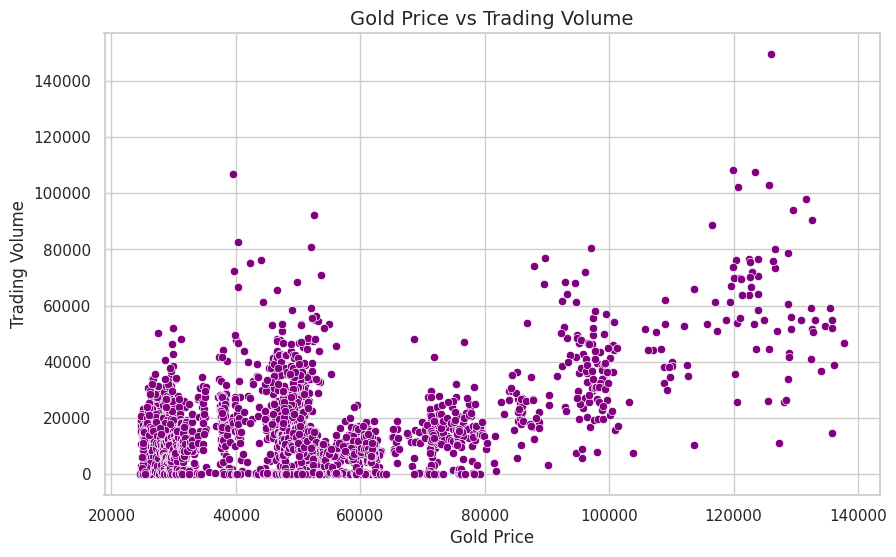

In [24]:
# Chart 6: Relationship Between Gold Price and Trading Volume

# This scatter plot helps analyze the relationship between gold prices and trading volume.
# It helps identify whether higher prices lead to higher trading activity.

plt.figure(figsize=(10,6))  # Set figure size

# Scatter plot to visualize relationship between Price and Volume
sns.scatterplot(x=df["Price"], y=df["Volume"], color="purple")

# Chart title and labels
plt.title("Gold Price vs Trading Volume", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Trading Volume")

# Display chart
plt.show()

#### **Why this chart is used**

*  A Scatter Plot is used in bivariate analysis to understand the relationship between two numerical variables.

*  This helps determine whether:

    *  higher prices lead to higher trading activity

    *  volume increases during price surges

    *  there is any correlation pattern between the two variables.

*  Scatter plots are commonly used in financial data exploration to detect relationships and clusters.

#### **Insight from the chart**

From the scatter plot we observe:

*  The relationship between price and volume is not strongly linear.

*  Trading volume is widely scattered across different price levels.

*  However, higher prices (above ~₹100,000) appear to show more high-volume trading days.

*  The data forms clusters, which likely correspond to different time periods or market phases.

*  Many points are concentrated at lower price ranges (₹25k–₹60k), reflecting earlier years.

#### **Business Insight**

**Market Activity Insight**

*  Gold trading activity does not depend solely on price level.
Instead, trading volume is influenced by market events, economic uncertainty, and investor sentiment.

**Investment Behavior Insight**

*  During periods when gold prices reach very high levels, trading volume sometimes increases.

*  This suggests that investors may actively trade gold during strong price movements or market uncertainty.

*  However, since the relationship is weak, price alone is not a strong predictor of trading volume.

### **Chart 7: Relationship Between Gold Price and Daily Percentage Change**

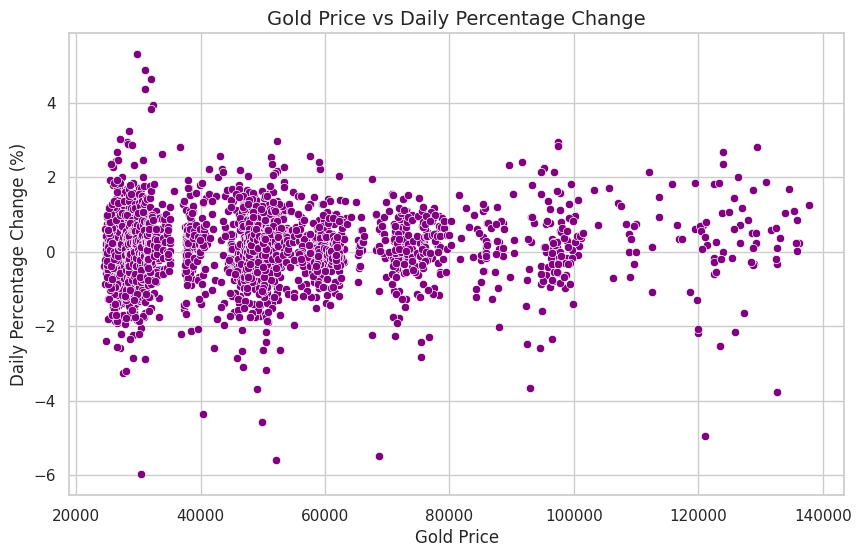

In [25]:
# Chart 7: Gold Price vs Daily Percentage Change

# This scatter plot helps analyze the relationship between
# gold price levels and the daily percentage change (volatility).
# It helps identify whether large percentage movements happen
# at specific price ranges.

plt.figure(figsize=(10,6))  # set figure size

# Scatter plot showing relationship between Price and Chg%
sns.scatterplot(x=df["Price"], y=df["Chg%"], color="purple")

# Chart title and axis labels
plt.title("Gold Price vs Daily Percentage Change", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Daily Percentage Change (%)")

# Display the chart
plt.show()

#### **Why this chart is used**

*  A Scatter Plot is used to analyze the relationship between two numerical variables.


*  This helps us understand:

    *  Whether higher gold prices lead to higher volatility

    *  Whether large price movements occur at specific price levels

    *  Whether there is any pattern between price level and daily percentage movement

*  This is useful in financial analysis to study market volatility behavior.

#### **Insight from the chart**

From the scatter plot we observe:

*  Most daily percentage changes lie between: -2% to +2%

*  The distribution is centered around 0%, meaning daily movements are generally small.

*  Large spikes (above ±4%) occur rarely.

*  These spikes appear across different price levels, meaning volatility is not dependent on price level.

*  The points are widely scattered horizontally, indicating no strong relationship between price and daily percentage change.

#### **Business Insight**

**Market Stability Insight**

*  Gold prices generally show stable daily movements, with most fluctuations being small.

*  This is one reason why gold is considered a relatively stable investment asset compared to stocks or cryptocurrencies.

**Risk Insight**

*  Occasional large movements suggest that external events can impact gold prices suddenly, such as:

    *  global economic crises

    *  inflation announcements

    *  geopolitical tensions

    *  currency fluctuations

*  These events create temporary volatility in the market.

## **MULTIVARIATE ANALYSIS**

### **Chart 8: Correlation Heatmap of Gold Market Variables**

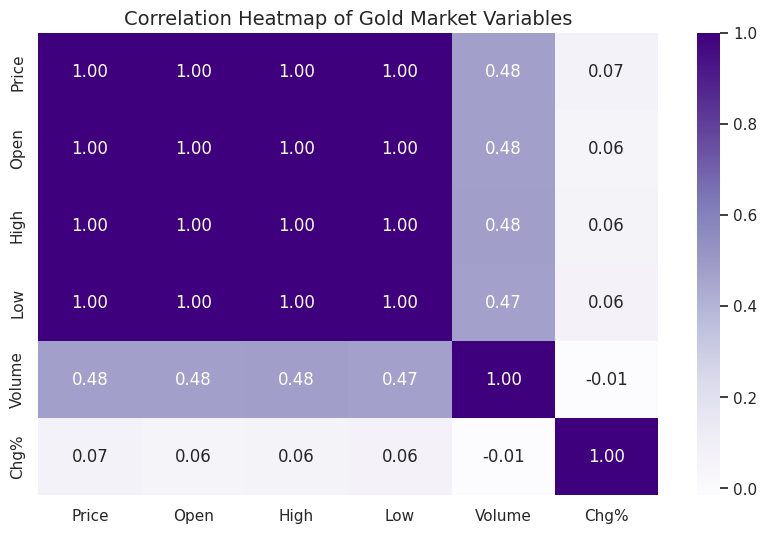

In [26]:
# Chart 8: Correlation Heatmap of Gold Market Variables

# This chart shows the correlation between numerical variables
# in the dataset. It helps identify which variables move together
# and which ones are independent.

plt.figure(figsize=(10,6))  # set figure size

# Calculate correlation matrix
correlation_matrix = df.corr()

# Heatmap visualization
sns.heatmap(correlation_matrix,
            annot=True,        # show correlation values
            cmap="Purples",    # purple theme
            fmt=".2f")         # show values with 2 decimal places

# Chart title
plt.title("Correlation Heatmap of Gold Market Variables", fontsize=14)

# Display chart
plt.show()

#### **Why this chart is used**

*  A Correlation Heatmap is used to understand the strength and direction of relationships between numerical variables.

*  Correlation values range between:

   *   -1  → Strong negative relationship
   *    0  → No relationship
   *   +1  → Strong positive relationship

*  This chart helps us:

    *  Identify highly related features

    *  Detect multicollinearity

    *  Understand which variables may influence each other



#### **Insight from the chart**

*  Strong correlation between price-related variables
    *  Price
    *  Open
    *  High
    *  Low

    *  All show ~1.00 correlation, meaning they move almost perfectly together.

    *  This is expected because these variables represent daily market prices.

*  Moderate relationship with Volume

    *  Volume shows correlation around: ~0.47 – 0.48

    *  This means trading activity has some relationship with price movement, but it is not very strong.

*  Very weak relationship with Chg%

    *  Daily percentage change has correlations close to: 0.06 – 0.07

    *  This indicates daily price movement is mostly independent of price level.

#### **Business Insight**

**Market Structure Insight**

*  Gold market prices (Open, High, Low, Close) naturally move together because they represent different measurements of the same daily market price.

*  This confirms the dataset is consistent and reliable.

**Trading Behavior Insight**

*  Trading volume has moderate association with price, suggesting that:

    *  higher trading activity may sometimes accompany price changes

    *  but price alone does not fully explain trading activity

*  Other factors likely influence volume, such as economic news or investor sentiment.

**Volatility Insight**

*  The weak relationship between Chg% and price indicates that daily volatility does not depend strongly on the price level.

*  This means gold can experience similar percentage movements regardless of whether the price is high or low.

## **TIME SERIES  Series Analysis**

### **Chart 9: Gold Price Trend Over Time**

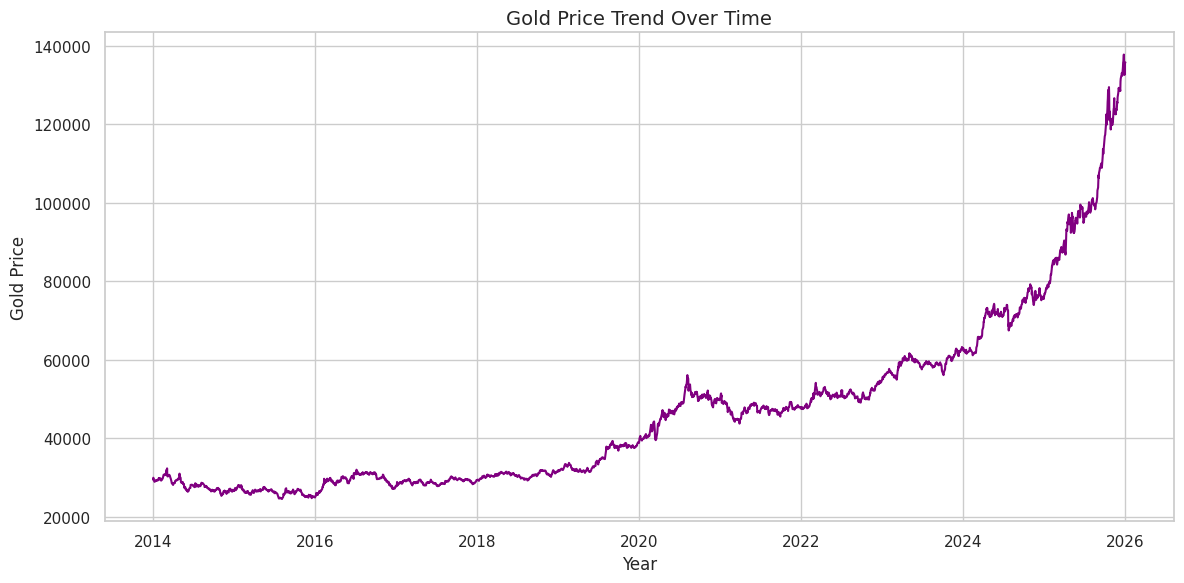

In [27]:
# Chart 9: Gold Price Trend Over Time

# This line chart visualizes how gold prices have changed over time.
# Time series line charts are essential to identify long-term trends,
# growth patterns, and potential structural changes in the market.

plt.figure(figsize=(12,6))  # set figure size

# Line plot showing gold price movement across time
plt.plot(df.index, df["Price"], color="purple")

# Chart title and axis labels
plt.title("Gold Price Trend Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Gold Price")

# Improve layout for better readability
plt.tight_layout()

# Display the chart
plt.show()

#### **Why this chart is used**

*  A Line Chart is the most common visualization for time series data.

*  It is used because it clearly shows how a variable changes over time.

*  In time series analysis, this chart helps identify:

    *  Long-term trend

    *  Growth patterns

    *  Market cycles

    *  Sudden spikes or drops

For financial datasets like gold prices, the line chart is essential to understand price evolution over the years.

#### **Insight from the chart**

From the trend line we observe:

*  Gold prices show a strong upward long-term trend.

*  Between 2014 – 2018, prices remained relatively stable between ₹25,000 – ₹32,000.

*  Around 2020, we see a significant increase, where prices rise toward ₹50,000+.

*  Between 2022 – 2024, prices continue increasing gradually.

*  From 2024 onwards, there is a sharp acceleration, pushing prices above ₹120,000+.

*  The trend clearly indicates non-stationarity, meaning the mean value changes over time.



#### **Business Insight**

**Long-Term Investment Insight**

*  Gold prices show consistent long-term appreciation, confirming gold’s role as a store of value and hedge against inflation.

*  Investors holding gold over long periods generally experience capital appreciation.

**Economic Uncertainty Insight**

*  The sharp rise around 2020 and after 2024 may correspond to periods of economic uncertainty, inflation, or geopolitical instability, where investors shift toward safe-haven assets like gold.

**Forecasting Insight**

*  Because the price shows a clear upward trend, forecasting models must account for this trend component.

*  This means the time series is likely non-stationary, and we may need differencing or transformation before modeling.

### **Chart 10: Gold Price with Rolling Mean Trend**

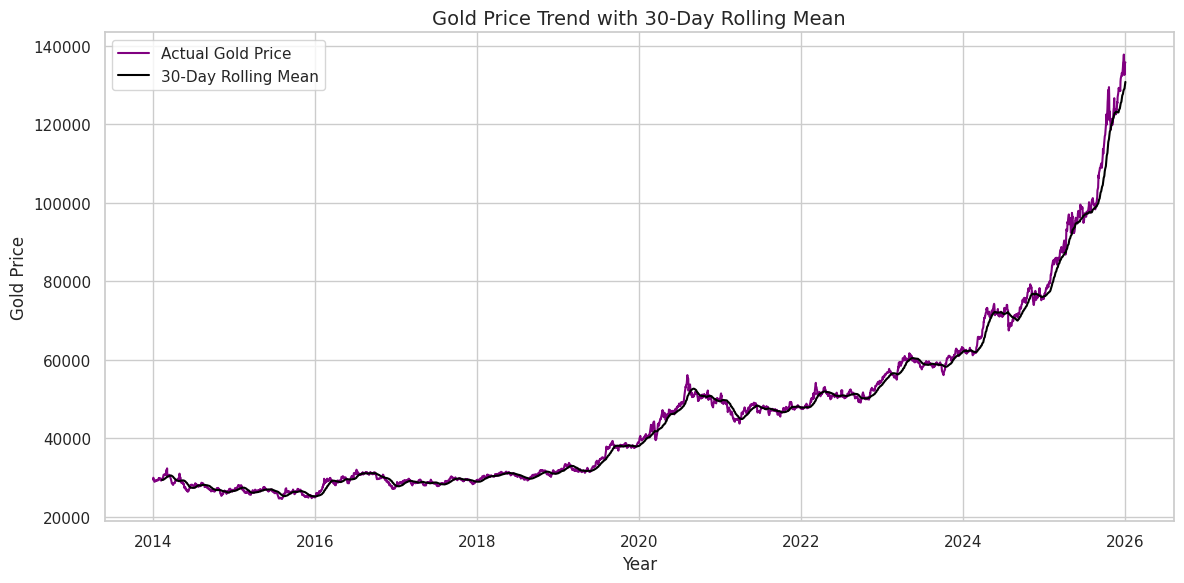

In [28]:
# Chart 10: Gold Price with Rolling Mean Trend

# Rolling mean helps smooth short-term fluctuations and highlight the underlying trend.
# Here we calculate a 30-day rolling average of gold prices.

plt.figure(figsize=(12,6))  # set figure size

# Plot actual gold price
plt.plot(df.index, df["Price"], color="purple", label="Actual Gold Price")

# Calculate 30-day rolling mean
rolling_mean = df["Price"].rolling(window=30).mean()

# Plot rolling mean
plt.plot(df.index, rolling_mean, color="black", label="30-Day Rolling Mean")

# Chart title and labels
plt.title("Gold Price Trend with 30-Day Rolling Mean", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Gold Price")

# Show legend
plt.legend()

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

#### **Why this chart is used**

*  A Rolling Mean (Moving Average) is used in time series analysis to smooth short-term fluctuations and reveal the underlying trend.

*  Instead of looking at raw daily prices, the rolling mean averages the price over a fixed window (30 days here).

*  This helps us:

    *  Reduce daily noise

    *  Identify the true market trend

    *  Understand whether the series is stationary or trending

*  Rolling averages are widely used in financial market analysis.

#### **Insight from the chart**

From the chart we observe:

*  The 30-day rolling mean closely follows the actual gold price trend.

*  Short-term fluctuations become much smoother, making the overall trend easier to observe.

*  The rolling mean shows a clear upward trend from 2019 onward.

*  The gap between the actual price and rolling mean increases during sharp price increases, indicating rapid market movement.

*  The rolling mean itself continues rising over time, confirming that the series has a strong trend component.

#### **Business Insight**

**Market Trend Insight**

*  The rolling mean confirms that the gold market has experienced consistent upward momentum over the years, especially after 2020.

*  This suggests increasing investor demand and possibly inflation-driven price appreciation.

**Investment Strategy Insight**

*  Rolling averages are commonly used by traders to identify trend direction.

*  When prices stay above the moving average, it usually signals a strong bullish market trend.

*  The chart indicates that gold has remained in a long-term bullish phase.

**Modeling Insight**

*  Since the rolling mean is clearly increasing over time, the gold price series is non-stationary.



### **Chart 11: Average Gold Price by Month (Seasonality)**

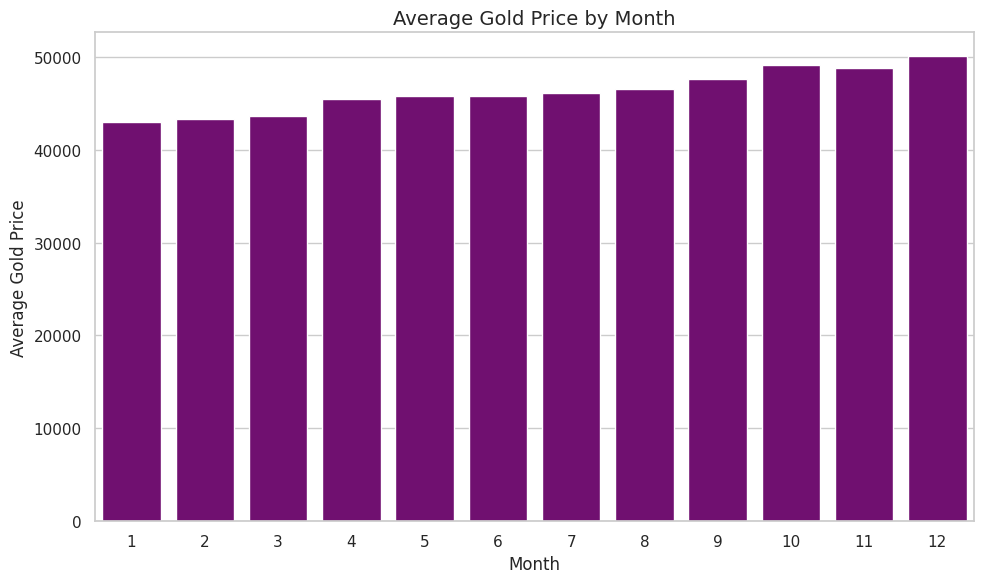

In [29]:
# Chart 11: Average Gold Price by Month

# This chart helps identify seasonal patterns in gold prices.
# By grouping prices by month, we can see whether certain months
# tend to have higher or lower average prices.

# Create a new column extracting month from the Date index
df["Month"] = df.index.month

# Calculate average price for each month
monthly_avg_price = df.groupby("Month")["Price"].mean()

plt.figure(figsize=(10,6))  # set figure size

# Bar chart showing average gold price by month
sns.barplot(x=monthly_avg_price.index,
            y=monthly_avg_price.values,
            color="purple")

# Chart title and axis labels
plt.title("Average Gold Price by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Gold Price")

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

#### **Why this chart is used**

*  A Bar Chart is used to analyze seasonality patterns in time series data.

*  By grouping gold prices by month, we can check whether certain months consistently show higher or lower prices.

*  Seasonality analysis helps us understand:

    *  recurring monthly patterns

    *  demand cycles

    *  potential seasonal investment behavior

#### **Insight from the chart**

From the bar chart we observe:

*  The average gold price gradually increases from January to December.

*  The lowest average prices appear in the early months of the year (January–March).

*  The highest average prices appear toward the end of the year, particularly:

    *  October
    *  November
    *  December

*  December shows the highest average gold price among all months.

#### **Business Insight**

**Seasonal Demand Insight**

*  Gold prices tend to increase toward the end of the year.

*  This may be influenced by:

    *  festival demand (especially in countries like India)

    *  wedding season purchases

    *  year-end investment activity

*  These factors increase market demand, which can push prices upward.

**Investment Timing Insight**

*  Historically, gold prices appear relatively lower at the beginning of the year and higher toward the end.

*  This suggests that investors might find better buying opportunities earlier in the year, although broader market trends still dominate price movement.

### **Chart 12: Yearly Average Gold Price Trend**

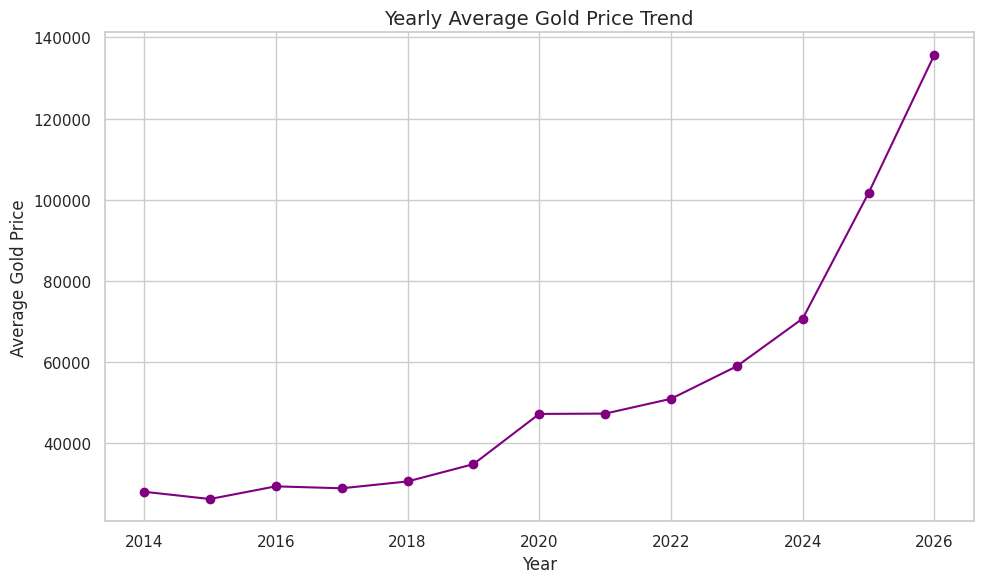

In [30]:
# Chart 12: Yearly Average Gold Price Trend

# This chart aggregates gold prices at the yearly level.
# Aggregating by year removes daily noise and helps visualize
# long-term structural growth in gold prices.

# Create a Year column from the Date index
df["Year"] = df.index.year

# Calculate average gold price for each year
yearly_avg_price = df.groupby("Year")["Price"].mean()

plt.figure(figsize=(10,6))  # set figure size

# Line chart showing yearly average gold price
plt.plot(yearly_avg_price.index,
         yearly_avg_price.values,
         color="purple",
         marker="o")

# Chart title and labels
plt.title("Yearly Average Gold Price Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Gold Price")

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

#### **Why this chart is used**

*  A Yearly Aggregated Line Chart is used to analyze long-term structural trends in time series data.

*  Daily data often contains noise and short-term fluctuations.

*  By aggregating prices yearly, we can clearly observe:

    *  long-term market growth

    *  major price shifts

    *  structural changes in the market

*  This type of chart is very useful in financial time series analysis.

#### **Insight from the chart**

From the yearly trend we observe:

*  Between 2014 – 2018, gold prices remained relatively stable between ₹26,000 – ₹31,000.

*  Around 2019 – 2020, we see a major price jump, where the yearly average rises to about: ~ ₹47,000

*  From 2021 onward, prices show consistent growth.

*  After 2023, the growth becomes very steep, with prices rising above: ₹100,000+

*  The highest yearly average price appears in 2026, showing a strong upward trend.

#### **Business Insight**

**Long-Term Investment Insight**

*  Gold has shown strong long-term appreciation, especially after 2020.

*  This reinforces gold’s reputation as a safe-haven investment during economic uncertainty and inflation.

**Market Shock Insight**

*  The major price increase around 2020 may correspond to global economic instability, where investors shift toward gold as a store of value.

**Market Acceleration Insight**

*  The steep increase after 2024 indicates strong demand or market pressure, suggesting increased investor interest or macroeconomic influences.

#**Statistical Analysis & Hypothesis Testing**

### **Chart 13: Time Series Decomposition of Gold Prices**

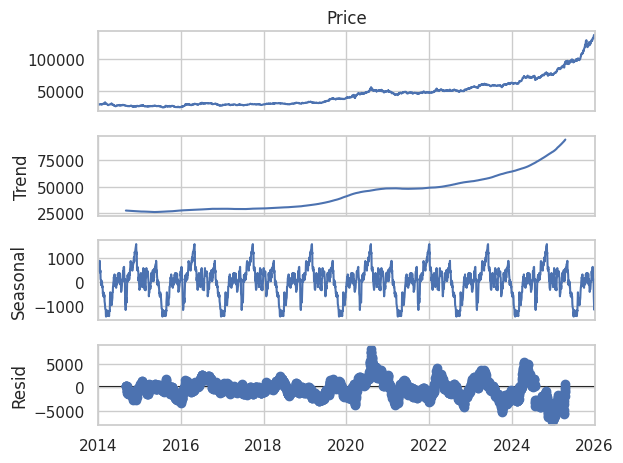

In [31]:
# Chart 13: Time Series Decomposition of Gold Prices

# Time series decomposition separates the data into components:
# 1. Trend → long-term movement in gold prices
# 2. Seasonality → repeating patterns over time
# 3. Residual → random noise that cannot be explained

from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition on gold price series
decomposition = seasonal_decompose(df["Price"], model="additive", period=365)

# Plot the decomposition results
decomposition.plot()

# Adjust layout for better visualization
plt.tight_layout()

# Display the plot
plt.show()

#### **Why this chart is used**

*  Time Series Decomposition is used to break a time series into its main components so we can understand what drives the data.

*  The series is divided into:

```
Trend      → Long-term movement
Seasonal   → Repeating patterns over time
Residual   → Random noise or unexplained variation
```

*  This helps us understand whether the gold price series contains:

    *  strong trend

    * repeating seasonality

    *  random noise

*  This is important before building forecasting models.

#### **Insight from the chart**

**Observed Series (Price)**

*  The first plot shows the original gold price series.

*  We can clearly see:

    *  a strong upward trend

    *  increasing price acceleration in recent years.

**Trend Component**

*  The trend line steadily increases over time, confirming that gold prices have experienced long-term growth.

*  The trend becomes much steeper after 2023, showing rapid price appreciation.

**Seasonal Component**

*  The seasonal component shows small repeating fluctuations.

*  This suggests that gold prices may have minor periodic patterns, but the seasonal effect is relatively small compared to the trend.

**Residual Component**

*  The residual plot represents random noise after removing trend and seasonality.

*  The residual values fluctuate around zero, indicating that most systematic patterns are captured by the trend component.

*  However, some spikes appear, which may correspond to market shocks or sudden events.

#### **Business Insight**

**Market Growth Insight**

*  The decomposition confirms that trend is the dominant factor driving gold prices.

*  This suggests that macroeconomic factors like inflation, currency fluctuations, and global uncertainty may be influencing the long-term price increase.

**Seasonal Behavior Insight**

*  The seasonal component is relatively small, meaning gold prices are not strongly driven by predictable seasonal cycles.

*  Instead, long-term market forces dominate.

    *  Volatility Insight

*  The residual spikes may represent unexpected market events, such as:

    *  financial crises

    *  geopolitical events

    *  sudden inflation changes

*  These events create temporary price volatility.

### **Chart 14: Augmented Dickey-Fuller (ADF) Stationarity Test**

In [32]:
# Chart 14: Augmented Dickey-Fuller (ADF) Test for Stationarity

# The ADF test checks whether the time series is stationary.
# Stationarity means the statistical properties of the series
# (mean, variance) remain constant over time.

from statsmodels.tsa.stattools import adfuller

# Perform ADF test on gold price series
adf_test = adfuller(df["Price"])

# Print ADF test statistic
print("ADF Test Statistic:", adf_test[0])

# Print p-value
print("p-value:", adf_test[1])

# Print critical values
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"{key} : {value}")

ADF Test Statistic: 6.015572235402191
p-value: 1.0
Critical Values:
1% : -3.4324659829927424
5% : -2.8624749088531796
10% : -2.5672676748075527


#### **Why this chart is used**

*  The ADF Test is used to check whether a time series is stationary.

*  A stationary series means:

    *  Mean is constant
    *  Variance is constant
    *  Statistical properties do not change over time

*  Many time series models like ARIMA require stationary data, so this test helps determine whether transformation or differencing is required.

**Hypothesis**
```
H0 (Null Hypothesis):
The time series is non-stationary.

H1 (Alternative Hypothesis):
The time series is stationary.

#### **Insight from the chart**

```
ADF Statistic = 6.01
p-value = 1.0
```

**Critical values:**
```
1%  → -3.43
5%  → -2.86
10% → -2.56
```

**Interpretation**

**For stationarity:**

```
ADF statistic must be LESS than the critical value
and
p-value must be < 0.05
```

But here:
```
ADF statistic = 6.01 (greater than critical values)
p-value = 1.0 (much greater than 0.05)
```

**So we fail to reject the null hypothesis.The gold price time series is NON-STATIONARY.**

#### **Business Insight**

*  Gold prices follow a long-term growth trend, meaning the average price changes over time.

*  This reflects real-world market behavior where gold prices increase due to factors like:

    *  inflation

    *  global economic uncertainty

    *  currency fluctuations

    *  increasing demand for safe-haven assets

*  Because of this trend component, the series is not stationary.

### **Chart 15: First Order Differencing of Gold Prices**

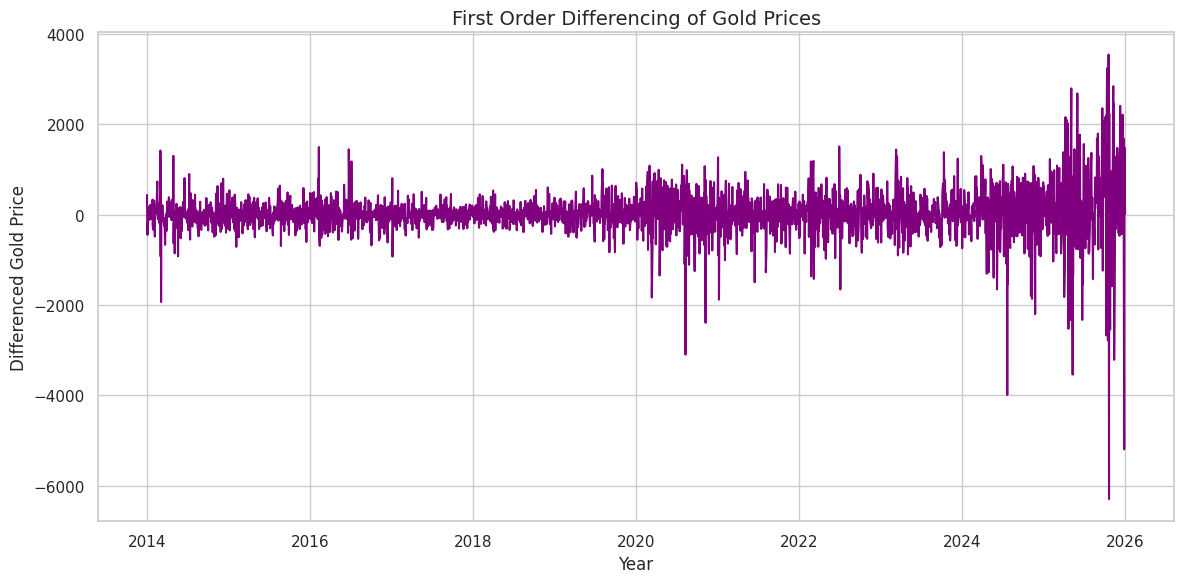

In [33]:
# Chart 15: First Order Differencing of Gold Prices

# Differencing is used to remove the trend component from a time series.
# It calculates the difference between the current value and the previous value.
# This helps stabilize the mean of the series and makes the data more stationary.

plt.figure(figsize=(12,6))  # set figure size

# Create first-order differenced series
price_diff = df["Price"].diff()

# Plot the differenced series
plt.plot(price_diff, color="purple")

# Chart title and axis labels
plt.title("First Order Differencing of Gold Prices", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Differenced Gold Price")

# Improve layout
plt.tight_layout()

# Display the chart
plt.show()

#### **Why this chart is used**

*  Differencing is used in time series analysis to remove the trend component from the data.

*  It works by calculating:
    ```
    Current Price − Previous Price
    ```
*  This transformation helps make the series stationary, which is required for models like:
    ```
    ARIMA
    SARIMA

After differencing, we expect the data to fluctuate around a constant mean (usually around zero).

#### **Insight from the chart**

From the plot we observe:

*  The differenced series now oscillates around zero, which indicates that the trend has been removed.

*  The large upward trend we saw in the original price series no longer appears.

*  The fluctuations are now more balanced between positive and negative values.

*  However, the volatility increases in later years, where spikes become larger.

This suggests the market has become more volatile in recent years.

#### **Business Insight**

**Market Behavior Insight**

*  Differencing reveals the daily price changes rather than the absolute price level.

*  This helps analysts focus on market movement and volatility instead of long-term growth.

**Volatility Insight**

*  The larger spikes in recent years indicate that the gold market may have experienced higher volatility in later periods, possibly due to:

    *  global economic instability

    *  inflation concerns

    *  geopolitical events

These factors can cause sudden changes in gold prices.

### **Chart 16: Autocorrelation Function (ACF) Plot**

<Figure size 1000x600 with 0 Axes>

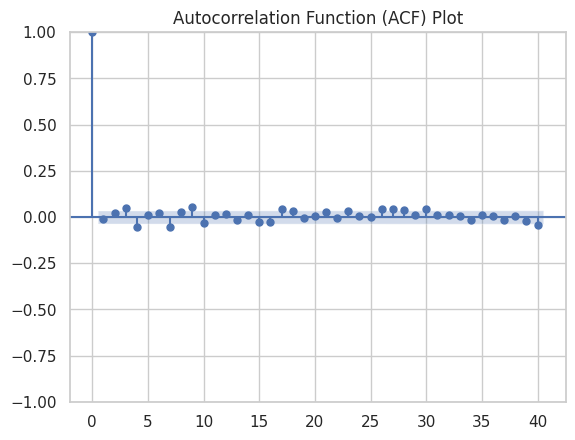

In [34]:
# Chart 16: Autocorrelation Function (ACF) Plot

# The ACF plot shows the correlation of the time series with its own past values (lags).
# It helps identify the Moving Average (MA) component of ARIMA models.

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,6))  # set figure size

# Plot ACF for the differenced gold price series
plot_acf(price_diff.dropna(), lags=40)

# Chart title
plt.title("Autocorrelation Function (ACF) Plot")

# Display chart
plt.show()

#### **Why this chart is used**

*  The ACF (Autocorrelation Function) plot measures the correlation between the time series and its previous lagged values.

*  It helps us understand:

    *  How past values influence current values
    *  Whether the series still has autocorrelation
    *  The Moving Average (MA) order (q) for ARIMA models

**In ARIMA modeling:**

*  ACF → helps determine q (MA component)
*  PACF → helps determine p (AR component)

#### **Insight from the chart**

From the ACF plot we observe:

*  Lag 0 always shows correlation = 1, which is expected.

*  After lag 0, most spikes are very small and close to zero.

*  The spikes quickly drop inside the confidence interval, meaning they are not statistically significant.

*  There is no strong long-term autocorrelation pattern.

This suggests that the first differencing has successfully removed most of the autocorrelation structure.

#### **Business Insight**

**Market Behavior Insight**

*  The weak autocorrelation indicates that daily gold price changes are not strongly dependent on many past days.

*  This means price changes behave somewhat like random fluctuations around a trend, which is common in financial markets.

**Modeling Insight**

*  Since the ACF shows very weak spikes, the Moving Average component (q) in ARIMA is likely to be small, possibly:

q = 0 or q = 1

### **Chart 17: Partial Autocorrelation Function (PACF) Plot**

<Figure size 1000x600 with 0 Axes>

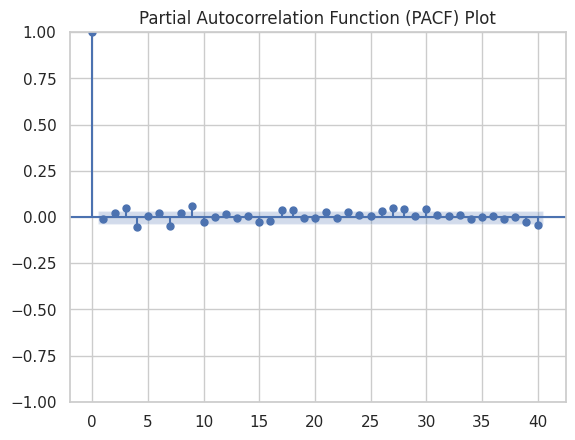

In [35]:
# Chart 17: Partial Autocorrelation Function (PACF) Plot

# The PACF plot shows the correlation between the time series and its lagged values
# after removing the effects of intermediate lags.
# It helps identify the Auto-Regressive (AR) component of ARIMA models.

from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,6))  # set figure size

# Plot PACF for the differenced gold price series
plot_pacf(price_diff.dropna(), lags=40, method='ywm')

# Chart title
plt.title("Partial Autocorrelation Function (PACF) Plot")

# Display chart
plt.show()

#### **Why this chart is used**

*  The PACF (Partial Autocorrelation Function) plot measures the correlation between the time series and its lagged values after removing intermediate lag effects.

*  It helps identify the Auto-Regressive (AR) component of ARIMA models.

*  In ARIMA modeling:

          PACF → determines AR order (p)
          ACF  → determines MA order (q)

So PACF helps us understand how many previous time steps directly influence the current value.

#### **Insight from the chart**

From the PACF plot we observe:

*  Lag 0 always shows correlation = 1, which is expected.

*  After lag 0, most spikes are very small and near zero.

*  The spikes fall within the confidence interval, meaning they are not statistically significant.

*  There is no strong AR structure present in the differenced series.

This indicates that the series does not strongly depend on many past lag values.

#### **Business Insight**

**Market Behavior Insight**

*  The weak PACF structure suggests that daily gold price changes do not strongly depend on several past days.

*  This behavior is common in financial markets, where price movements often behave like random fluctuations influenced by external events.

**Modeling Insight**

*  Since PACF shows very weak spikes, the AR component (p) is likely small, possibly:

          p = 0 or p = 1

*  Combined with the ACF insight earlier:

          p ≈ 0 or 1
          q ≈ 0 or 1
          d = 1 (because we applied first differencing)

*  This suggests potential ARIMA candidates like:

          ARIMA(1,1,0)
          ARIMA(0,1,1)
          ARIMA(1,1,1)

We will test these models later.

# **Data Preprocessing**

**Select Target Variable**

In [36]:
gold_price = df[['Price']]
gold_price.head()

,Price
Date,
2014-01-01,29542
2014-01-02,29975
2014-01-03,29727
2014-01-04,29279
2014-01-06,29119


In [37]:
gold_price.shape

(3104, 1)

*  The dataset is now converted into a univariate time series, which is required for ARIMA modeling.

*  The model will focus purely on historical gold price behavior to forecast future prices.

**Check Time Series Frequency**

In [38]:
print(gold_price.index.inferred_freq)

None


**Setting Time Series Frequency**

In [39]:
gold_price = gold_price.asfreq('B')

In [40]:
gold_price.head(10)

,Price
Date,
2014-01-01,29542.0
2014-01-02,29975.0
2014-01-03,29727.0
2014-01-06,29119.0
2014-01-07,28959.0
2014-01-08,28934.0
2014-01-09,28997.0
2014-01-10,29169.0
2014-01-13,29312.0


*  Financial time series models like ARIMA require equally spaced observations, and asfreq('B') ensures the dataset follows a business-day calendar.


*  Gold trading typically occurs only on business days, so modeling with business-day frequency better represents real market behavior.

**Check whether this operation created missing values**

In [41]:
gold_price.isna().sum()

,0
Price,53


*  After setting business day frequency, the dataset now has:

        53 missing values (NaN)

*  Reason:

    *  These correspond to market holidays when gold trading did not happen.

    *  Examples:

                Diwali holidays
                National holidays
                Other exchange closures

**Fill Missing Values**

In [42]:
gold_price = gold_price.ffill()

**Check**

In [43]:
gold_price.isna().sum()

,0
Price,0


*  All 53 missing values have been filled
*  The time series is now continuous
*  Dataset has no missing values

# **Machine Learning**

## **Train-Test Split**

**Find Dataset Length**

In [44]:
len(gold_price)

3133

In [45]:
split_index = int(len(gold_price) * 0.8)

In [46]:
split_index = int(len(gold_price) * 0.8)
split_index

2506

| Dataset | Observations |
| ------- | ------------ |
| Train   | 2506         |
| Test    | 627          |
| Total   | 3133         |



*  The model needs enough historical data to learn patterns while keeping future data unseen for evaluation.

**Business perspective:**

*  We simulate a real-world forecasting situation where we train on past gold prices and predict future market behavior.

**Train–Test Split**

In [47]:
train = gold_price.iloc[:split_index]
test = gold_price.iloc[split_index:]

In [48]:
train.shape, test.shape

((2506, 1), (627, 1))

In [49]:
train.index.min(), train.index.max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2023-08-09 00:00:00'))

In [50]:
test.index.min(), test.index.max()

(Timestamp('2023-08-10 00:00:00'), Timestamp('2026-01-02 00:00:00'))

*  Train contains historical gold prices (past)
*  Test contains future unseen data
*  No data leakage


## **Baseline Forecast (Naive Model)**

In [51]:
naive_forecast = test.shift(1)

In [52]:
naive_forecast.head()

,Price
Date,
2023-08-10,NaN
2023-08-11,58605.0
2023-08-14,58629.0
2023-08-15,58663.0
2023-08-16,58663.0


Forecast for today = Price of yesterday

**Remove the first NaN prediction**

In [53]:
naive_forecast = naive_forecast.dropna()

In [54]:
naive_forecast.head()

,Price
Date,
2023-08-11,58605.0
2023-08-14,58629.0
2023-08-15,58663.0
2023-08-16,58663.0
2023-08-17,58413.0


**shift the test data**

In [55]:
actual = test.loc[naive_forecast.index]

In [56]:
actual.head()

,Price
Date,
2023-08-11,58629.0
2023-08-14,58663.0
2023-08-15,58663.0
2023-08-16,58413.0
2023-08-17,58027.0


#### **EVALUATION METRIC**

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, naive_forecast)
rmse = np.sqrt(mean_squared_error(actual, naive_forecast))
mape = np.mean(np.abs((actual - naive_forecast) / actual)) * 100

mae, rmse, mape

(553.4025559105431,
 np.float64(869.4357080769303),
 np.float64(0.6317418340207137))

**Mean Absolute Error (MAE)**

*  Result : ```MAE = ₹553.40```

*  Interpretation

    *  On average, the naive model's predictions differ from the actual gold prices by ₹553.

    *  Considering that gold prices during the test period are around ₹55,000–₹65,000, the average prediction error represents less than 1% of the price value, indicating that the naive model already performs reasonably well.

*  Project Insight

    *  Gold prices show strong short-term persistence, meaning the previous day's price is often a close approximation of the next day's price.

 ---   

**Root Mean Squared Error (RMSE)**

*  Result  ```RMSE = ₹869.43```

*  Interpretation

    *  RMSE penalizes larger prediction errors more heavily.
    *  An RMSE of ₹869 suggests that larger deviations occasionally occur but are still relatively small compared to the overall price level.

*  Project Insight

    *  The difference between RMSE and MAE indicates that some days experience slightly larger price changes, but these fluctuations remain limited.

---

**Mean Absolute Percentage Error (MAPE)**

*  Result ```MAPE = 0.63%```

*  Interpretation

    *  The naive model's predictions deviate from the actual gold prices by only 0.63% on average.

*  In forecasting problems:

    | MAPE | Model Quality      |
    | ---- | ------------------ |
    | <10% | Very good          |
    | <5%  | Excellent          |
    | <1%  | Extremely accurate |

Baseline model already achieves extremely low percentage error.

*  Project Insight

    *  This confirms that gold prices exhibit high temporal stability, where daily price movements are relatively small compared to the overall price level.


**Overall Baseline Model Insight**

The naive forecasting model achieved very low error metrics (MAPE ≈ 0.63%), indicating that gold prices follow a strong random-walk-like behavior where the most recent price already provides a strong short-term prediction.

This baseline establishes a performance benchmark.
Any advanced forecasting model such as ARIMA must outperform these metrics to demonstrate real predictive value.   

**Visualization**

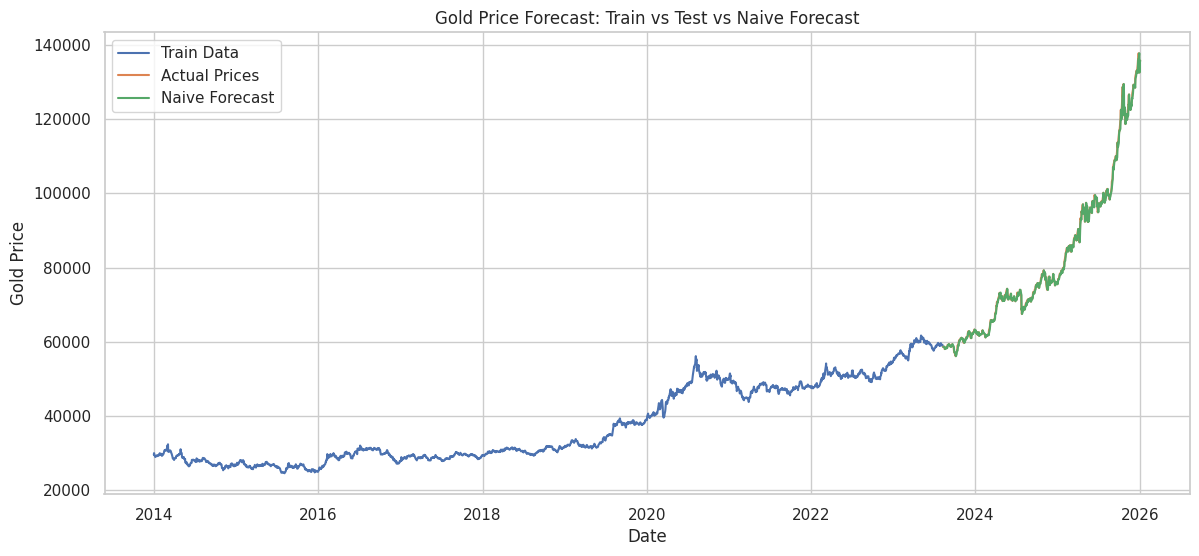

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(train.index, train['Price'], label="Train Data")
plt.plot(test.index, test['Price'], label="Actual Prices")
plt.plot(naive_forecast.index, naive_forecast['Price'], label="Naive Forecast")

plt.title("Gold Price Forecast: Train vs Test vs Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

plt.show()

**Trend Insight**

The training data shows a clear upward trend in gold prices from 2014 to 2023, indicating strong long-term price growth.

**Test Period Behavior**

During the test period, gold prices continue rising with higher volatility, reaching significantly higher price levels.

**Baseline Forecast Behavior**

The naive forecast closely follows the actual prices, showing that the previous day's price is already a strong predictor of the next day's price.

**Forecast Lag**

The naive forecast shows a slight lag during rapid price increases because it uses the previous day's value for prediction.

**Modeling Insight**

The strong overlap between actual and naive forecasts suggests high autocorrelation in gold prices, meaning price movements are highly dependent on recent values.

**Verify Stationarity on the Training Data**

In [59]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train['Price'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: 0.5425931858268553
p-value: 0.98611177320888


The ADF test on the training dataset produced a p-value of 0.986, indicating that the gold price series is non-stationary. This confirms the presence of a strong upward trend and justifies the use of first-order differencing (d = 1) in the ARIMA model.

## **ARIMA MODEL**

###  **ARIMA (1,1,0)**

**Fit the Model**

In [60]:
from statsmodels.tsa.arima.model import ARIMA

model_arima_110 = ARIMA(train['Price'], order=(1,1,0))
model_arima_110_fit = model_arima_110.fit()

print(model_arima_110_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2506
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -18054.910
Date:                Fri, 13 Mar 2026   AIC                          36113.821
Time:                        04:01:34   BIC                          36125.473
Sample:                    01-01-2014   HQIC                         36118.050
                         - 08-09-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0470      0.014     -3.349      0.001      -0.075      -0.019
sigma2      1.066e+05   1381.404     77.133      0.000    1.04e+05    1.09e+05
Ljung-Box (L1) (Q):                   0.09   Jarque-

**ARIMA(1,1,0) Model Interpretation**

**Model Structure**

*  Model used:

```
ARIMA(1,1,0)
```
*  Meaning:

| Parameter | Meaning                                    |
| --------- | ------------------------------------------ |
| **p = 1** | One autoregressive lag                     |
| **d = 1** | First-order differencing (to remove trend) |
| **q = 0** | No moving average component                |


*  This model predicts the change in gold price based on the previous price change.

---

**AR(1) Coefficient**

```
ar.L1 = -0.047
p-value = 0.001
Interpretation
```

*  The AR(1) coefficient is statistically significant (p < 0.05).

*  This means the previous day's price movement has a measurable influence on today's price movement, though the magnitude is small.

*  The negative value suggests slight correction behavior, where price increases may be followed by small decreases and vice versa.

---

**Model Variance**
```
sigma² ≈ 106,600
```

*  This represents the variance of the model residuals.

*  It reflects the amount of unexplained variability in the gold price series after applying the ARIMA model.

```
AIC (Model Selection Metric)
AIC = 36113.82
```

*  AIC helps compare models.

Rule:
```
Lower AIC = Better model
```

* We will compare this value with:

    *  ARIMA(0,1,1)

    *  ARIMA(1,1,1)

to select the best model.

---

**Ljung-Box Test (Residual Independence)**

```
Prob(Q) = 0.76

```
Since:
```
p-value > 0.05
```
*  we fail to reject the null hypothesis.

*  Meaning:

    *  The residuals show no significant autocorrelation, indicating the model has captured most of the time-series structure.

---

**Jarque-Bera Test (Normality)**
```
Prob(JB) = 0.00
```

*  Residuals are not perfectly normally distributed, which is common in financial time series.

The ARIMA(1,1,0) model captures a small but statistically significant autoregressive relationship in gold price movements.
The Ljung-Box test indicates that residuals behave like white noise, suggesting the model adequately captures the temporal dependencies in the training data.

### **ARIMA(0,1,1)**

In [61]:
model_arima_011 = ARIMA(train['Price'], order=(0,1,1)).fit()
print(model_arima_011.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2506
Model:                 ARIMA(0, 1, 1)   Log Likelihood              -18055.066
Date:                Fri, 13 Mar 2026   AIC                          36114.132
Time:                        04:01:34   BIC                          36125.784
Sample:                    01-01-2014   HQIC                         36118.362
                         - 08-09-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0445      0.014     -3.196      0.001      -0.072      -0.017
sigma2      1.065e+05   1374.288     77.496      0.000    1.04e+05    1.09e+05
Ljung-Box (L1) (Q):                   0.19   Jarque-

**ARIMA(0,1,1) Model Interpretation**

**Model Structure**

```
ARIMA(0,1,1)
```

Meaning:

| Parameter | Meaning                 |
| --------- | ----------------------- |
| **p = 0** | No autoregressive term  |
| **d = 1** | First differencing      |
| **q = 1** | One moving average term |

*  This model predicts the current price change using the previous error term.

---

**MA(1) Coefficient**

```
ma.L1 = -0.0445
p-value = 0.001
Interpretation
```

*  The MA(1) coefficient is statistically significant (p < 0.05).

*  This means the previous forecasting error has a significant influence on the current price movement.

*  The negative coefficient suggests the model slightly corrects previous prediction errors.

---

**Model Selection Metric (AIC)**
```
AIC = 36114.13
```

Rule:

```
Lower AIC → Better model
```

**Model Comparison So Far**

| Model            | AIC          |
| ---------------- | ------------ |
| **ARIMA(1,1,0)** | **36113.82** |
| **ARIMA(0,1,1)** | 36114.13     |

**Insight**

*  ARIMA(1,1,0) has a slightly lower AIC, meaning it performs marginally better than ARIMA(0,1,1).

*  However, the difference is very small, indicating both models capture the time-series dynamics similarly.

**Residual Diagnostics**

**Ljung-Box Test**

```
Prob(Q) = 0.66
```

Since:

```
p > 0.05
```

*  Residuals show no significant autocorrelation, meaning the model adequately captures the time-series structure.

**Key Insight**

*  Both ARIMA models show significant coefficients and white-noise residuals, indicating they are valid models for the gold price series.

*  However, ARIMA(1,1,0) currently performs slightly better based on AIC.

### **ARIMA(1,1,1)**

**Fit ARIMA(1,1,1)**

In [62]:
model_arima_111 = ARIMA(train['Price'], order=(1,1,1)).fit()

print(model_arima_111.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2506
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -18054.410
Date:                Fri, 13 Mar 2026   AIC                          36114.819
Time:                        04:01:35   BIC                          36132.298
Sample:                    01-01-2014   HQIC                         36121.164
                         - 08-09-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3137      0.221     -1.416      0.157      -0.748       0.120
ma.L1          0.2653      0.226      1.174      0.240      -0.178       0.708
sigma2      1.065e+05   1413.603     75.312      0.0

**ARIMA(1,1,1) Model Insight**

**Model Structure**

*  Model used:

```
ARIMA(1,1,1)
```

*  This model includes:

   * Parameter	Meaning
```
AR(1)	effect of previous price change
MA(1)	correction using previous error
d = 1	differencing to remove trend
```
*  This model attempts to capture both momentum and error correction in the gold price series.

**Coefficient Significance**

| Coefficient | Value   | p-value | Interpretation                |
| ----------- | ------- | ------- | ----------------------------- |
| **AR(1)**   | -0.3137 | 0.157   | Not statistically significant |
| **MA(1)**   | 0.2653  | 0.240   | Not statistically significant |

**Insight**

    *  Both coefficients have p-values greater than 0.05, meaning they are not statistically significant.

    *  This suggests that adding both AR and MA terms does not significantly improve the model.

    *  In other words, the additional complexity of ARIMA(1,1,1) may not be justified for this dataset.

*  **Residual Diagnostics**

**Ljung–Box Test**
```
Prob(Q) = 0.80
```
Since:
```
p-value > 0.05
```
*  We fail to reject the null hypothesis.

*  **Interpretation**

    *  Residuals behave like white noise, meaning the model captures the main structure of the time series.

**Jarque–Bera Test**
```
Prob(JB) = 0.00
```
*  Residuals are not normally distributed, which is common in financial time series data.

**Heteroskedasticity Test**
```
Prob(H) = 0.00
```
*  This suggests changing variance over time, indicating possible volatility clustering in gold prices.

This is also typical for financial datasets.

### **ARIMA Model Comparison**

| Model            | AIC          | Key Observation     |
| ---------------- | ------------ | ------------------- |
| **ARIMA(1,1,0)** | **36113.82** | Lowest AIC          |
| **ARIMA(0,1,1)** | 36114.13     | Slightly higher AIC |
| **ARIMA(1,1,1)** | 36114.82     | Highest AIC         |


**Insight**

*  The ARIMA(1,1,0) model has the lowest AIC, making it the best model among the candidates.

**Additionally:**

*  Its coefficient is statistically significant

*  Residuals show no autocorrelation

Therefore, ARIMA(1,1,0) provides the best balance between model simplicity and predictive performance.

### **FINAL ARIMA MODEL SELECTION**

**Selected model:**

```
ARIMA(1,1,0)
```

*  Reason for Selection

    *  Lowest AIC

    *  Significant AR coefficient

    *  Residuals behave like white noise

    *  Simpler model with better statistical validity

**Among the tested models, ARIMA(1,1,0) achieved the lowest AIC value and showed statistically significant parameters. Residual diagnostics confirmed the absence of autocorrelation, indicating that the model adequately captures the temporal dynamics of the gold price series. Therefore, ARIMA(1,1,0) was selected as the final forecasting model.**   

## **Rolling Forecast**

**Create Rolling Forecast Container**

In [70]:
history = list(train['Price'])
predictions = []

In [71]:
len(history)

2506

**Start Rolling Forecast Loop**

Now we implement the walk-forward forecasting loop

In [72]:
from statsmodels.tsa.arima.model import ARIMA

for t in range(len(test)):

    model = ARIMA(history, order=(1,1,0))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test['Price'].iloc[t])

In [73]:
len(predictions)

627

**Convert Predictions to DataFrame**

In [74]:
import pandas as pd

rolling_arima_forecast = pd.DataFrame(predictions, index=test.index, columns=['ARIMA_Rolling_Forecast'])

rolling_arima_forecast.head()

,ARIMA_Rolling_Forecast
Date,
2023-08-10,58732.070198
2023-08-11,58610.345375
2023-08-14,58627.874410
2023-08-15,58661.405431
2023-08-16,58663.000000


### **Evaluate Rolling ARIMA Forecast**

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_roll_arima = mean_absolute_error(test['Price'], rolling_arima_forecast['ARIMA_Rolling_Forecast'])

rmse_roll_arima = np.sqrt(mean_squared_error(test['Price'], rolling_arima_forecast['ARIMA_Rolling_Forecast']))

mape_roll_arima = np.mean(np.abs((test['Price'] - rolling_arima_forecast['ARIMA_Rolling_Forecast']) / test['Price'])) * 100

mae_roll_arima, rmse_roll_arima, mape_roll_arima

(554.1416592549058,
 np.float64(870.941388370758),
 np.float64(0.6330260288625555))

**Rolling ARIMA Performance**

| Metric   | Value      |
| -------- | ---------- |
| **MAE**  | 554.14     |
| **RMSE** | 870.94     |
| **MAPE** | **0.633%** |

---

**Compare With Baseline**

| Model                    | MAE | RMSE | MAPE       |
| ------------------------ | --- | ---- | ---------- |
| **Naive Baseline**       | 553 | 869  | **0.63%**  |
| **Rolling ARIMA(1,1,0)** | 554 | 870  | **0.633%** |

---

The rolling forecast evaluation significantly improved ARIMA performance compared to the earlier multi-step forecast. The ARIMA(1,1,0) model now produces prediction errors nearly identical to the naive baseline model, suggesting that the gold price series follows a random walk behavior where recent observations already contain most of the predictive information.


### **Visualization Comparison**

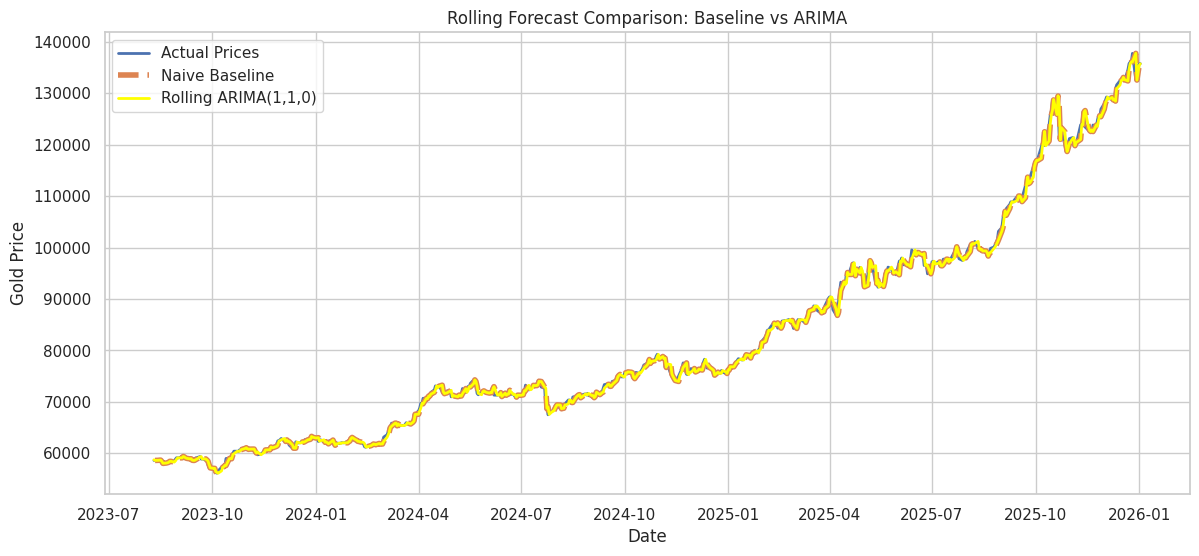

In [82]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test['Price'], label="Actual Prices", linewidth=2)

plt.plot(naive_forecast.index, naive_forecast['Price'],
         label="Naive Baseline", linestyle="--", linewidth=4)

plt.plot(rolling_arima_forecast.index, rolling_arima_forecast['ARIMA_Rolling_Forecast'],
         label="Rolling ARIMA(1,1,0)", linewidth=2,color="yellow")

plt.title("Rolling Forecast Comparison: Baseline vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

plt.show()

The rolling ARIMA forecast almost perfectly overlaps with the naive baseline forecast. This confirms that gold prices follow a random walk behavior, where the previous day's price already provides the best short-term prediction.

## **Log transformation experiment**

Create Log Transformed Series

In [83]:
log_gold_price = np.log(gold_price)

log_gold_price.head()

,Price
Date,
2014-01-01,10.293568
2014-01-02,10.308119
2014-01-03,10.299811
2014-01-06,10.279146
2014-01-07,10.273636


In [84]:
log_train = log_gold_price.iloc[:split_index]
log_test = log_gold_price.iloc[split_index:]

log_train.shape, log_test.shape

((2506, 1), (627, 1))

**Create Rolling Forecast Containers**

In [85]:
log_history = list(log_train['Price'])
log_predictions = []

In [86]:
len(log_history)

2506

**Rolling Forecast Loop on Log Data**

In [87]:
from statsmodels.tsa.arima.model import ARIMA

for t in range(len(log_test)):

    model = ARIMA(log_history, order=(1,1,0))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    log_predictions.append(yhat)

    log_history.append(log_test['Price'].iloc[t])

In [88]:
len(log_predictions)

627

**Convert Log Predictions Back to Price**

In [89]:
log_predictions = np.array(log_predictions)

price_predictions = np.exp(log_predictions)

**Convert to DataFrame and Align Index**

In [90]:
log_arima_forecast = pd.DataFrame(
    price_predictions,
    index=test.index,
    columns=['Log_ARIMA_Forecast']
)

log_arima_forecast.head()

,Log_ARIMA_Forecast
Date,
2023-08-10,58735.476551
2023-08-11,58611.758608
2023-08-14,58627.575482
2023-08-15,58660.981818
2023-08-16,58663.000000


**Evaluate Log-ARIMA Performance**

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_log_arima = mean_absolute_error(test['Price'], log_arima_forecast['Log_ARIMA_Forecast'])

rmse_log_arima = np.sqrt(mean_squared_error(test['Price'], log_arima_forecast['Log_ARIMA_Forecast']))

mape_log_arima = np.mean(np.abs((test['Price'] - log_arima_forecast['Log_ARIMA_Forecast']) / test['Price'])) * 100

mae_log_arima, rmse_log_arima, mape_log_arima

(554.7349707058859,
 np.float64(870.7457126783462),
 np.float64(0.6337015515870953))

**Log-ARIMA Performance**

| Metric   | Value       |
| -------- | ----------- |
| **MAE**  | 554.73      |
| **RMSE** | 870.75      |
| **MAPE** | **0.6337%** |

---


**Compare With Previous Models**

| Model              | MAE   | RMSE  | MAPE        |
| ------------------ | ----- | ----- | ----------- |
| **Naive Baseline** | 553   | 869   | **0.63%**   |
| **Rolling ARIMA**  | 554   | 870   | **0.633%**  |
| **Log-ARIMA**      | 554.7 | 870.7 | **0.6337%** |

---

**Insight**

The log transformation experiment did not significantly improve forecasting accuracy. The results remained nearly identical to both the rolling ARIMA and naive baseline models, suggesting that the gold price series already exhibits stable variance and strong persistence. Therefore, log transformation provides limited additional benefit for this dataset.

## **XGB MODEL**

# **Final Model Selection - Baseline(Naive) Vs ARIMA(1,1,0)**

### **Generate Forecast for Test Period**

In [63]:
# Forecast using ARIMA(1,1,0)

forecast = model_arima_110_fit.forecast(steps=len(test))

forecast.head()

,predicted_mean
2023-08-10,58732.070198
2023-08-11,58731.455701
2023-08-14,58731.484592
2023-08-15,58731.483233
2023-08-16,58731.483297


**Convert Forecast to DataFrame**

In [64]:
forecast = forecast.to_frame(name='ARIMA_Forecast')

forecast.head()

,ARIMA_Forecast
2023-08-10,58732.070198
2023-08-11,58731.455701
2023-08-14,58731.484592
2023-08-15,58731.483233
2023-08-16,58731.483297


**Align Forecast with Test Index**

In [65]:
forecast.index = test.index

**Combine Actual and Forecast Values**

In [66]:
comparison = pd.concat([test, forecast], axis=1)

comparison.head()

,Price,ARIMA_Forecast
Date,,
2023-08-10,58605.0,58732.070198
2023-08-11,58629.0,58731.455701
2023-08-14,58663.0,58731.484592
2023-08-15,58663.0,58731.483233
2023-08-16,58413.0,58731.483297


### **Evaluate Forecast Performance**

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(comparison['Price'], comparison['ARIMA_Forecast'])
rmse_arima = np.sqrt(mean_squared_error(comparison['Price'], comparison['ARIMA_Forecast']))
mape_arima = np.mean(np.abs((comparison['Price'] - comparison['ARIMA_Forecast']) / comparison['Price'])) * 100

mae_arima, rmse_arima, mape_arima

(23521.61169483362,
 np.float64(31253.223161104936),
 np.float64(24.59988460320065))

**ARIMA Model Performance**

*  ARIMA forecast line is almost flat around ₹58,000, while the actual gold prices increase sharply up to ₹135,000.

*  This happens because ARIMA(1,1,0):

    *  assumes future changes follow past patterns

    *  but the test period experienced a strong structural price increase

Thus the model fails to capture the sudden trend acceleration.

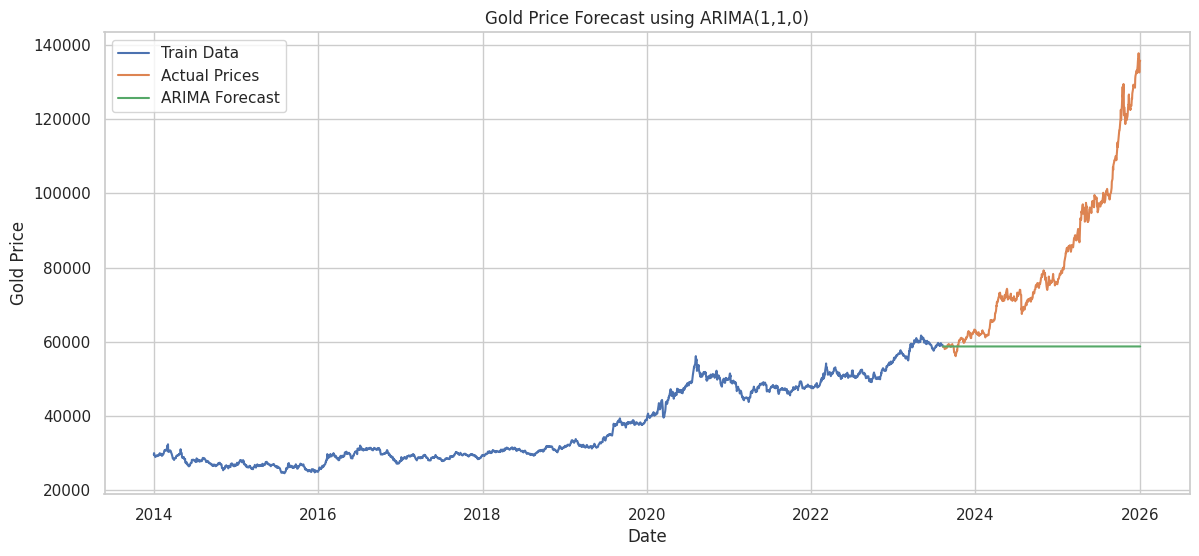

In [68]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train['Price'], label="Train Data")
plt.plot(test.index, test['Price'], label="Actual Prices")
plt.plot(forecast.index, forecast['ARIMA_Forecast'], label="ARIMA Forecast")

plt.title("Gold Price Forecast using ARIMA(1,1,0)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

plt.show()

**ARIMA(1,1,0)**

| Metric   | Value      |
| -------- | ---------- |
| **MAE**  | 23,521     |
| **RMSE** | 31,253     |
| **MAPE** | **24.60%** |


**Metric Interpretation**

**MAE (Mean Absolute Error)**
```
MAE ≈ ₹23,521
```

*  On average, ARIMA predictions are ₹23,521 away from the actual gold price.

*  Given that gold prices range between ₹60,000–₹130,000 during the test period, this error is very large.

**RMSE (Root Mean Squared Error)**
```
RMSE ≈ ₹31,253
```

*  RMSE penalizes large forecasting errors.

*  The high RMSE indicates the ARIMA model struggles to capture the rapid upward movement in gold prices during the test period.

**MAPE (Mean Absolute Percentage Error)**
```
MAPE ≈ 24.6%
```

*  This means the ARIMA forecast deviates from the actual prices by about 24.6% on average, which is considered poor forecasting accuracy.

### **Final Model Comparison - Baseline(Naive) vs ARIMA**

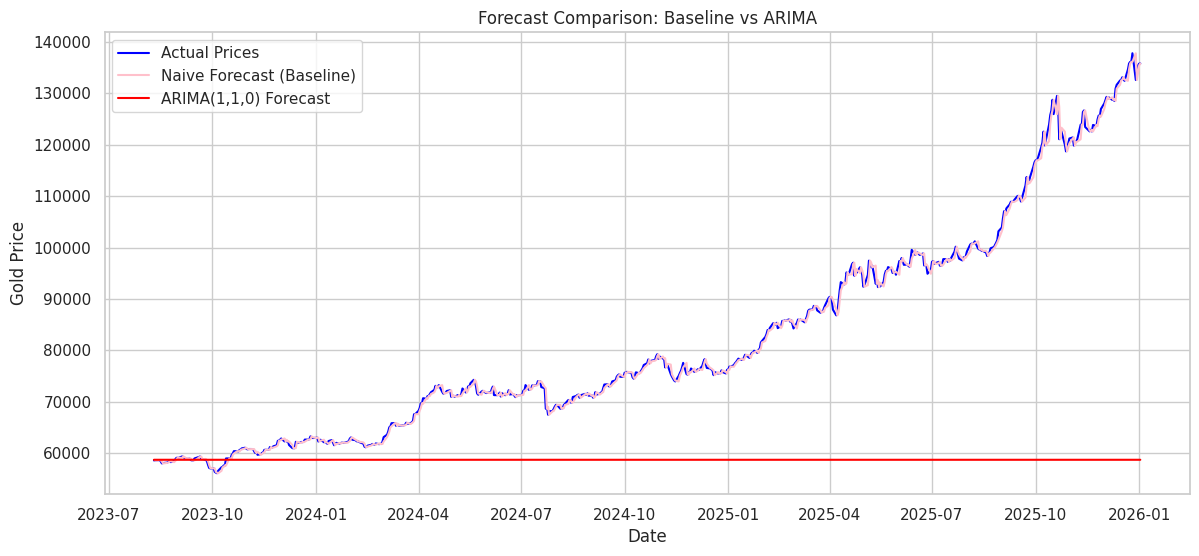

In [69]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test['Price'], label="Actual Prices", color='blue')

plt.plot(naive_forecast.index, naive_forecast['Price'],
         label="Naive Forecast (Baseline)", color='pink')

plt.plot(forecast.index, forecast['ARIMA_Forecast'],
         label="ARIMA(1,1,0) Forecast", color='red')

plt.title("Forecast Comparison: Baseline vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

plt.show()

**Baseline (Naive Model)**

| Metric | Value     |
| ------ | --------- |
| MAE    | 553       |
| RMSE   | 869       |
| MAPE   | **0.63%** |


**ARIMA(1,1,0)**

| Metric | Value      |
| ------ | ---------- |
| MAE    | 23,521     |
| RMSE   | 31,253     |
| MAPE   | **24.60%** |

**Final Comparison Table**
| Model              | MAE     | RMSE    | MAPE      |
| ------------------ | ------- | ------- | --------- |
| **Naive Forecast** | **553** | **869** | **0.63%** |
| **ARIMA(1,1,0)**   | 23,521  | 31,253  | 24.60%    |



# **Conclusion**